제공해주신 과적합 방지 기법 내용을 가독성을 극대화하고 수학적 수식을 수식 전용 포맷($inline$ 및

$$display$$

)으로 정돈한 문서입니다.

---

## 05. 과적합 문제와 방지 기법

**TensorFlow / Google Colab**

모델이 복잡해질수록 파라미터(Parameter)가 늘어나고 가중치의 절댓값이 비대해져 과적합(Overfitting)이 발생하기 쉽습니다. 즉, 훈련 데이터의 손실은 계속 줄어들지만 검증/테스트 데이터의 손실은 오히려 증가하는 현상입니다.

$$ L_{\text{train}} \downarrow \quad \text{but} \quad \ L_{\text{test}} \uparrow$$

---

## 과적합 방지를 위한 3대 기법

### 1) 정규화 (Regularization)

손실 함수(Loss Function)에 가중치의 크기에 비례하는 **패널티 항**을 추가하여 모델의 복잡도를 강제로 제어하는 방법입니다.

* **L1 정규화 (Lasso)**: 가중치 절댓값의 합을 더해줍니다. 불필요한 가중치를 정확히 $0$으로 수렴하게 만들어 모델을 희소(Sparse)하게 만듭니다.

$$ L_{L1} = L + \lambda \sum_i \vert{}w_i\vert{}$$


* **L2 정규화 (Ridge)**: 가중치 제곱합을 더해줍니다. 특정 가중치가 비대해지는 것을 **강하게 억제**하며, 딥러닝에서 가장 보편적으로 사용됩니다.

$$ L_{L2} = L + \lambda \sum_i w_i^2$$



> **$\lambda$ (하이퍼파라미터)**: 규제의 강도를 조절하는 계수입니다. 값이 클수록 모델의 가중치를 더 강하게 억제합니다.

### 2) 드롭아웃 (Dropout)

네트워크의 과도한 상호의존성(Co-adaptation)을 깨뜨리기 위해 도입된 강력한 알고리즘입니다.

* **학습 시 (Training)**: 은닉층의 뉴런을 설정된 확률에 따라 **무작위로 끄고(Drop)** 잔여 뉴런들로만 순전파와 역전파를 수행합니다.
* **테스트 시 (Testing)**: **모든 뉴런을 활성화**하되, 훈련 시의 앙상블 효과를 반영하기 위해 출력값에 드롭아웃 확률을 곱해 스케일을 조정합니다.

### 3) 배치 정규화 (Batch Normalization)

학습 과정에서 계층별 입력 분포가 계속 변하는 '내부 공변량 변화(Internal Covariate Shift)' 문제를 해결하기 위해, 완전연결층(FC)과 활성화 함수 **사이**에서 입력을 정규화합니다.

$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \varepsilon}}$$

$$y = \gamma \hat{x} + \beta$$

* $\mu_B, \sigma_B^2$: 현재 미니배치(Mini-batch)의 평균과 분산
* $\varepsilon$: 분모가 $0$이 되는 것을 방지하는 아주 작은 상수
* $\gamma, \beta$: 정규화로 인해 데이터의 표현력이 제한되는 것을 막기 위해 모델이 스스로 학습하는 **스케일($\gamma$) 및 시프트($\beta$) 하이퍼파라미터**
* **핵심 장점**: 가중치 초기화 기법에 대한 의존도 감소, 과적합 억제(자체적인 규제 효과), 안정적인 경사 하강으로 인한 **학습 속도 향상**

## 0. 환경 설정


In [1]:
# Colab에는 TensorFlow가 기본 설치되어 있습니다.
import sys
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 운영체제가 macOS('darwin')가 아닐 경우 (예: 구글 코랩 등 리눅스 환경),
# 한글 출력을 위한 나눔 폰트를 설치하고 폰트 캐시를 초기화합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

import seaborn as sns

# 나눔 폰트 파일 시스템 경로를 순회하며 matplotlib 폰트 관리자에 등록합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# matplotlib 및 seaborn의 기본 설정을 변경합니다 (한글 깨짐 방지, 마이너스 부호 깨짐 방지, 고해상도 설정)
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))



Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

## 과적합이 나기 쉬운 작은 데이터셋


In [2]:
import numpy as np

# 1. 실험 조건 설정: 데이터 수에 비해 차원이 매우 높은 환경 정의
# 학습용 데이터는 120개로 매우 적은 반면, 특징(Feature)은 30개로 매우 많음 -> 과적합 발생 최적의 조건
n_train, n_test, d = 120, 400, 30

# 2. 훈련(Train) 데이터 생성 (평균 0, 표준편차 1인 표준정규분포)
X_train = np.random.randn(n_train, d).astype("float32")

# 타깃(y) 생성 공식: 30개의 특징 중 오직 0번과 1번 특징만 결정에 참여 (나머지 2~29번은 아무 쓸모 없는 무작위 노이즈 데이터)
# 약간의 임의성(0.3 * 정규분포 노이즈)을 더한 뒤, 0보다 크면 1, 작으면 0으로 분류하는 이진 분류 타깃 생성
y_train = ((1.2*X_train[:,0] - 0.8*X_train[:,1] + 0.3*np.random.randn(n_train)) > 0).astype("float32")

# 3. 테스트(Test) 데이터 생성 (훈련 데이터와 동일한 메커니즘으로 동작하지만 별도로 분리된 평가용 데이터)
X_test = np.random.randn(n_test, d).astype("float32")
y_test = ((1.2*X_test[:,0] - 0.8*X_test[:,1] + 0.3*np.random.randn(n_test)) > 0).astype("float32")

# 4. 데이터 세트의 형태(Shape) 출력하여 정상 생성 확인
print("train", X_train.shape, "test", X_test.shape)

train (120, 30) test (400, 30)


## 공통: 모델 만들기 함수 (기법만 바꿈)


In [3]:
def build_model(use_l1=False, use_l2=False, dropout=0.0, use_bn=False):
    """
    설정값에 따라 과적합 방지 기법 조합을 유연하게 적용하여 모델을 생성하는 함수
    """
    reg = None
    # 1. 가중치 정규화(Regularization) 객체 설정
    if use_l1:
        reg = keras.regularizers.l1(1e-4) # L1 규제 계수 0.0001
    if use_l2:
        reg = keras.regularizers.l2(1e-3) # L2 규제 계u 0.001 (둘 다 True일 경우 L2가 최종 적용됨)

    m = keras.Sequential()
    m.add(layers.Input(shape=(30,))) # 입력층 정의 (특징 수: 30)

    # 2. 3개의 은닉층(Hidden Layer)을 반복하여 생성
    for _ in range(3):
        # Batch Normalization을 사용할 경우, Dense의 bias(편향)는 불필요하므로 제거 (use_bias=False)
        m.add(layers.Dense(64, kernel_regularizer=reg, use_bias=not use_bn))

        # 배치 정규화 적용 (활성화 함수 직전에 입력 분포를 정규화)
        if use_bn:
            m.add(layers.BatchNormalization())

        m.add(layers.Activation("relu")) # 비선형 활성화 함수 적용

        # 드롭아웃 적용 (설정된 확률만큼 뉴런을 무작위로 turn-off)
        if dropout > 0:
            m.add(layers.Dropout(dropout))

    # 3. 출력층 및 컴파일 (이진 분류 문제이므로 시그모이드와 binary_crossentropy 사용)
    m.add(layers.Dense(1, activation="sigmoid"))
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m


def run(name, **kwargs):
    """
    지정된 설정으로 모델을 60 에포크 동안 학습시키고 최종 성능 지표를 출력하는 함수
    """
    # 1. 위에서 정의한 함수로 조합형 모델 빌드
    model = build_model(**kwargs)

    # 2. 모델 학습 진행 (verbose=0으로 중간 로그 생략)
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test), # 검증 데이터 지정
        epochs=60, batch_size=16, verbose=0,
    )

    # 3. 학습 종료 후 훈련 데이터와 테스트 데이터의 최종 성능(Loss, Accuracy) 평가
    tr = model.evaluate(X_train, y_train, verbose=0)
    te = model.evaluate(X_test, y_test, verbose=0)

    # 4. 결과 출력: train_acc와 test_acc의 차이(gap)를 계산하여 과적합 수준을 한눈에 파악
    # gap이 클수록 모델이 훈련 데이터만 암기(과적합)했음을 의미합니다.
    print(f"{name:14s} | train_acc={tr[1]:.3f} | test_acc={te[1]:.3f} | gap={tr[1]-te[1]:.3f}")

    return hist, model

## 1) Baseline vs L1 / L2 / Dropout / BatchNorm


### 1. 실험의 목적 및 환경

- **목적**: 과적합이 일어나기 매우 쉬운 극단적인 환경에서 **L1, L2 정규화, 드롭아웃, 배치 정규화**가 실제 모델의 학습(Train Loss)과 검증(Test Loss)에 어떤 영향을 미치는지 비교 분석합니다.
- **환경 (과적합 유도)**: 훈련 데이터는 단 120개로 매우 적은 반면, 특징(Feature)은 30개로 매우 많으며, 그중 28개는 정답과 상관없는 무의미한 노이즈 데이터입니다.

---

### 2. 기법별 실험 결과 및 특징 분석

- **baseline (규제 없음)**
  + **훈련 손실**: 가장 빠르게 0에 수렴합니다 (훈련 데이터를 완벽하게 암기).
  + **테스트 손실**: 에포크가 지날수록 손실 값이 하늘로 폭발합니다. **가장 심각한 과적합(Overfitting)** 상태를 보여줍니다.


- **L1 / L2 정규화 (가중치 규제)**
  + **메커니즘**: 손실 함수에 패널티 항을 추가하여 가중치가 비대해지는 것을 막습니다.
  + **결과**: 훈련 손실이 감소하는 속도는 다소 느려지지만, 테스트 손실이 일정 수준 이상으로 치솟지 않도록 **안정적으로 붙잡아 줍니다.**


- **Dropout (드롭아웃)**
  + **메커니즘**: 뉴런을 무작위로 끄며 학습하여 특정 뉴런에만 의존하는 현상을 방지합니다.
  + **결과**: 모델이 노이즈에 강해지며, 훈련 손실과 테스트 손실 사이의 **일반화 격차(Gap)를 줄이는 데 매우 효과적**입니다.


- **BatchNorm (배치 정규화)**
  + **메커니즘**: 레이어 사이의 입력 분포를 정규화하여 가중치 초기화 의존도를 낮춥니다.
  + **결과**: **초반 학습 속도(Train Loss 하강)를 엄청나게 부스팅**해 주며, 자체적인 규제 효과로 테스트 손실도 베이스라인보다 안정적입니다.


- **BN + Dropout (복합 규제)**
  + **결과**: 배치 정규화의 빠른 학습 속도와 드롭아웃/L2의 강력한 과적합 억제력이 결합하여, **가장 빠르고 안정적인 최적의 테스트 성능**을 보여주는 경향이 있습니다.

### 핵심 시사점

- 규제가 없는 모델은 소수의 데이터를 완벽하게 암기(`baseline`)하여 겉보기엔 완벽해 보이지만 실전(Test)에서 무너집니다.
- 데이터가 부족하고 노이즈가 많은 실제 필드 환경일수록 **배치 정규화로 학습 속도를 올리고, 드롭아웃과 L2 정규화로 과적합을 방지하는 복합 설계가 필수적**입니다.


baseline       | train_acc=1.000 | test_acc=0.770 | gap=0.230
L2             | train_acc=1.000 | test_acc=0.842 | gap=0.158
L1             | train_acc=1.000 | test_acc=0.832 | gap=0.168
Dropout        | train_acc=1.000 | test_acc=0.810 | gap=0.190
BatchNorm      | train_acc=0.992 | test_acc=0.752 | gap=0.239
BN+Dropout     | train_acc=1.000 | test_acc=0.788 | gap=0.212


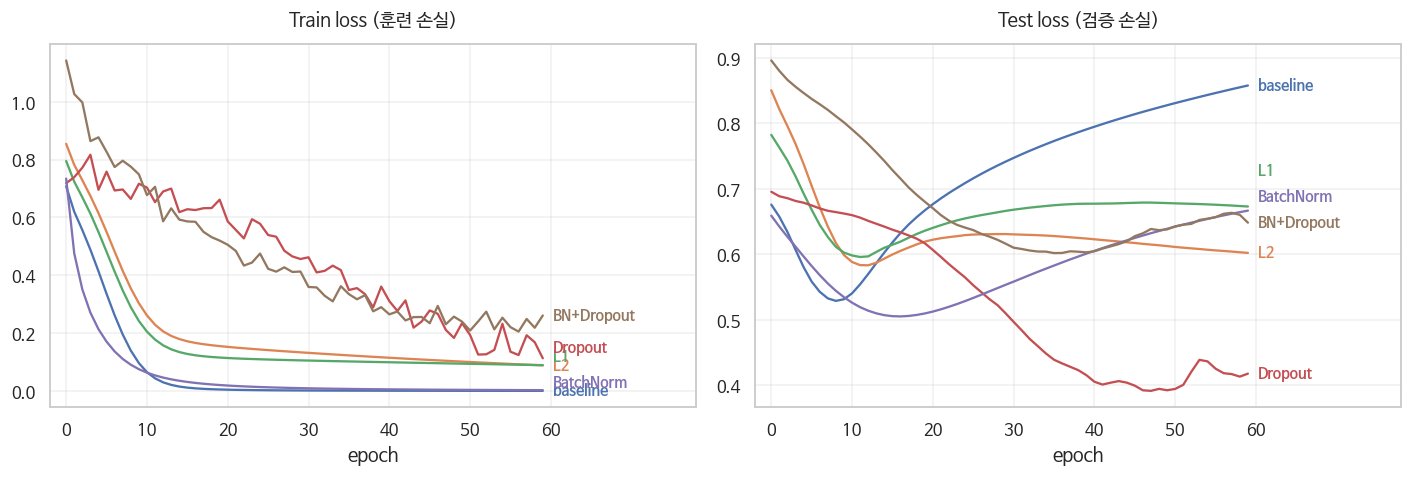

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# (데이터 생성 및 run 함수 정의 부분은 기존과 동일하다고 가정합니다)

results = {}
results["baseline"] = run("baseline")
results["L2"] = run("L2", use_l2=True)
results["L1"] = run("L1", use_l1=True)
results["Dropout"] = run("Dropout", dropout=0.5)
results["BatchNorm"] = run("BatchNorm", use_bn=True)
results["BN+Dropout"] = run("BN+Dropout", use_bn=True, dropout=0.3, use_l2=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 텍스트 조정을 위해 각 플롯별 라벨 정보를 모아둘 리스트
train_labels = []
test_labels = []

for name, (hist, _) in results.items():
    train_loss = hist.history["loss"]
    test_loss = hist.history["val_loss"]
    epochs = list(range(len(train_loss)))

    # 그래프 플롯 (색상을 기억하기 위해 line 객체 확보)
    line0, = axes[0].plot(epochs, train_loss)
    line1, = axes[1].plot(epochs, test_loss)

    # 마지막 좌표와 색상 정보를 리스트에 저장
    train_labels.append({'name': name, 'x': epochs[-1], 'y': train_loss[-1], 'color': line0.get_color()})
    test_labels.append({'name': name, 'x': epochs[-1], 'y': test_loss[-1], 'color': line1.get_color()})

# 글자 겹침을 막기 위해 Y값 기준으로 위치를 재조정하는 함수
def draw_adjusted_labels(ax, labels, min_diff=0.03):
    # Y값 기준으로 오름차순 정렬
    labels.sort(key=lambda item: item['y'])

    # 겹치는 부분이 있으면 위로 밀어 올리는 알고리즘
    for i in range(1, len(labels)):
        if labels[i]['y'] - labels[i-1]['y'] < min_diff:
            labels[i]['y'] = labels[i-1]['y'] + min_diff

    # 조정된 위치에 글자 출력
    for item in labels:
        ax.text(item['x'] + 1.2, item['y'], item['name'],
                color=item['color'],
                fontsize=9.5,
                va='center',
                fontweight='bold')

# 두 그래프에 각각 겹침 방지 라벨 적용
draw_adjusted_labels(axes[0], train_labels, min_diff=0.03)
draw_adjusted_labels(axes[1], test_labels, min_diff=0.04)

# 스타일링 설정
axes[0].set_title("Train loss (훈련 손실)", pad=12)
axes[1].set_title("Test loss (검증 손실)", pad=12)

for ax in axes:
    ax.set_xlabel("epoch")
    ax.set_xlim(-2, 78) # 여백 확보
    ax.set_xticks(range(0, 61, 10))
    ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## 2) Dropout: 학습(train) vs 예측(test)

- 텐서플로(TensorFlow) 모델을 호출할 때 `training` 인자를 `True`로 주느냐, `False`로 주느냐에 따른 내부 메커니즘의 차이를 보여줍니다.

### 1) `training=True` (학습 모드): 드롭아웃 활성화 (ON)

- **동작:** 모델에게 "지금은 학습 중이야"라고 알려주는 설정입니다. 이때 드롭아웃 레이어는 설정된 확률(여기서는 0.5)에 따라 **뉴런을 무작위로 끄기 시작**합니다.
- **결과:** 동일한 입력 데이터 `x`를 연속으로 두 번 넣어도(`y1`, `y2`), 첫 번째 호출할 때 꺼진 뉴런들과 두 번째 호출할 때 꺼진 뉴런들이 서로 다릅니다. 따라서 출력값이 매번 달라지게 되며, `y1 - y2` 의 평균 차이는 **0이 아닌 양수**가 나옵니다.

### 2) `training=False` (테스트 모드): 드롭아웃 비활성화 (OFF)

- **동작:** 모델에게 "지금은 실전 테스트(혹은 배포) 중이야"라고 알려주는 설정입니다. 이때 드롭아웃 레이어는 **뉴런을 끄지 않고 모든 뉴런을 활성화**합니다. (대신 학습 때 뉴런이 꺼졌던 비율을 고려해 출력값의 스케일만 조정합니다.)
- **결과:** 모델이 무작위성 없이 고정된 계산만 수행하는 '결정론적(Deterministic)' 상태가 됩니다. 따라서 동일한 입력 데이터 `x`를 몇 번을 넣든 항상 똑같은 출력값(`y3 == y4`)을 반환하므로, 둘의 차이는 **정확히 0.0**이 나옵니다.

## 딥러닝 관점에서의 핵심 시사점


- **학습할 때 무작위로 다른 뉴런을 끄는 이유:**
모델의 뉴런들이 서로 너무 강하게 결합하여 특정 뉴런에만 의존하는 현상(Co-adaptation)을 강제로 깨뜨리기 위함입니다. 매 에포크마다 서로 다른 수많은 미니 네트워크를 학습시키는 일종의 **앙상블(Ensemble) 효과**를 내어 과적합을 방지합니다.
- **테스트할 때 드롭아웃을 끄는 이유:**
실전 배포나 모델 평가를 할 때, 똑같은 사진이나 데이터를 넣었는데 누를 때마다 정답 레이블이나 확률이 다르게 바뀌면 안 되기 때문입니다. 항상 **일관되고 안정적인 최선의 예측 결과**를 얻기 위해 테스트 모드에서는 드롭아웃을 끕니다.




In [6]:
model = build_model(dropout=0.5)
# 같은 입력에 대해 training=True / False 출력 비교
x = X_train[:5]

# 학습 모드처럼 Dropout ON
y1 = model(x, training=True)
y2 = model(x, training=True)
# 테스트 모드 Dropout OFF
y3 = model(x, training=False)
y4 = model(x, training=False)

print("train모드 두 번 차이(평균):", float(tf.reduce_mean(tf.abs(y1 - y2))))
print("test모드  두 번 차이(평균):", float(tf.reduce_mean(tf.abs(y3 - y4))))
print("→ 학습 때는 매번 다른 뉴런이 꺼지고, 테스트는 결과가 같습니다.")


train모드 두 번 차이(평균): 0.4252278208732605
test모드  두 번 차이(평균): 0.0
→ 학습 때는 매번 다른 뉴런이 꺼지고, 테스트는 결과가 같습니다.


## 정리
| 기법 | 한 줄 요약 |
|------|------------|
| L1 | 불필요 가중치 ≈ 0 (희소) |
| L2 | 가중치 크기 전반 억제 |
| Dropout | 학습 시 뉴런 무작위 제거 |
| BatchNorm | 층 입력 정규화 → 학습 가속 + 규제 |
